In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# --- System Parameters ---
fifo_depth = 16
words_per_row = 8
spi_read_time_ns = 200

In [3]:
# ==============================================================================
# 1. Simulate FIFO Overflow over Time (At 1.0 us Query Interval)
# ==============================================================================
query_interval_fast_ns = 1000
num_queries = 25

reads_per_query_fast = int(query_interval_fast_ns / spi_read_time_ns)

fifo_levels = [0]
total_dropped = 0
dropped_history = [0]

current_level = 0

for _ in range(num_queries):
    # Imager dumps 8 words
    current_level += words_per_row
    
    # SPI reads words during the interval
    current_level -= reads_per_query_fast
    
    # Calculate overflow and clamp to depth
    if current_level > fifo_depth:
        total_dropped += (current_level - fifo_depth)
        current_level = fifo_depth
    elif current_level < 0:
        current_level = 0
        
    fifo_levels.append(current_level)
    dropped_history.append(total_dropped)

In [4]:
# ==============================================================================
# 2. Calculate Steady-State Drop Rate vs. Query Interval
# ==============================================================================
query_intervals_us = np.linspace(0.8, 2.0, 100)
drop_rates = []

for interval in query_intervals_us:
    reads = np.floor((interval * 1000) / spi_read_time_ns)
    net_accum = words_per_row - reads
    
    if net_accum <= 0:
        drop_rates.append(0.0)
    else:
        drop_rates.append((net_accum / words_per_row) * 100)

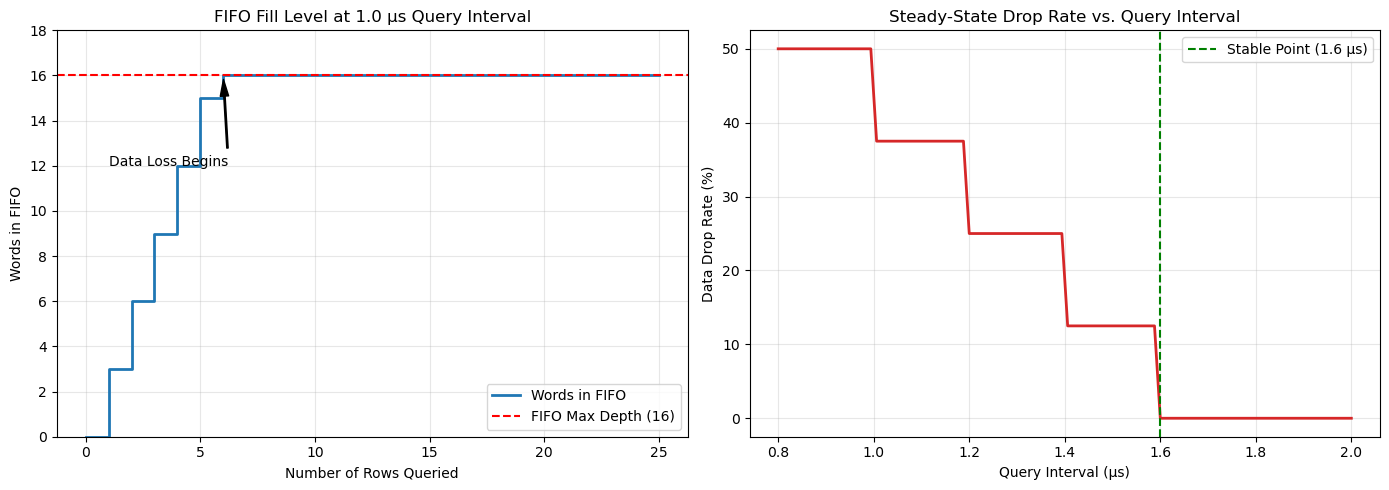

: 

In [ ]:
# ==============================================================================
# 3. Plotting
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Fill Level Timeline
queries = np.arange(num_queries + 1)
ax1.step(queries, fifo_levels, where='post', label='Words in FIFO', color='#1f77b4', linewidth=2)
ax1.axhline(y=fifo_depth, color='r', linestyle='--', label='FIFO Max Depth (16)')
ax1.set_title('FIFO Fill Level at 1.0 µs Query Interval')
ax1.set_xlabel('Number of Rows Queried')
ax1.set_ylabel('Words in FIFO')
ax1.set_ylim(0, fifo_depth + 2)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Annotate overflow point
overflow_idx = next(i for i, v in enumerate(fifo_levels) if v == fifo_depth)
ax1.annotate('Data Loss Begins', xy=(overflow_idx, fifo_depth), xytext=(overflow_idx - 5, fifo_depth - 4),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

# Plot 2: Drop Rate Sweep
ax2.plot(query_intervals_us, drop_rates, color='#d62728', linewidth=2)
ax2.axvline(x=1.6, color='g', linestyle='--', label='Stable Point (1.6 µs)')
ax2.set_title('Steady-State Drop Rate vs. Query Interval')
ax2.set_xlabel('Query Interval (µs)')
ax2.set_ylabel('Data Drop Rate (%)')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import ipywidgets as widgets
# from IPython.display import display, clear_output

In [ ]:
# # ==============================================================================
# # 1. The Core Update Function
# # ==============================================================================
# def update_dashboard(query_interval_us, spi_read_time_ns, words_per_row, fifo_depth):
#     # Core Math
#     reads_per_query = np.floor((query_interval_us * 1000) / spi_read_time_ns)
#     net_accum = words_per_row - reads_per_query
#     is_stable = net_accum <= 0
    
#     drop_rate = 0.0 if is_stable else (net_accum / words_per_row) * 100
#     time_to_overflow = "Stable" if is_stable else f"{((fifo_depth / net_accum) * query_interval_us):.1f} µs"

#     # --- Print Metrics ---
#     print("=" * 50)
#     print(f" SYSTEM STATUS: {'STABLE (No Overflow)' if is_stable else 'WARNING (Data Loss)'}")
#     print(f" Data Drop Rate: {drop_rate:.1f}%")
#     print(f" Time to Overflow: {time_to_overflow}")
#     print("=" * 50)

#     # --- Generate Plots ---
#     fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#     # Plot 1: Drop Rate Sweep
#     intervals = np.linspace(0.8, 2.5, 100)
#     rates = [0 if (words_per_row - np.floor((i * 1000) / spi_read_time_ns)) <= 0 
#              else ((words_per_row - np.floor((i * 1000) / spi_read_time_ns)) / words_per_row) * 100 
#              for i in intervals]
    
#     ax1.plot(intervals, rates, color='#d62728', linewidth=2)
#     ax1.axvline(x=query_interval_us, color='b', linestyle='--', label=f'Current: {query_interval_us}µs')
#     ax1.set_title('Drop Rate vs. Query Interval')
#     ax1.set_xlabel('Query Interval (µs)')
#     ax1.set_ylabel('Data Drop Rate (%)')
#     ax1.grid(True, alpha=0.3)
#     ax1.legend()

#     # Plot 2: Simulated FIFO Fill Level
#     num_queries = 20
#     levels = [0]
#     current = 0
#     for _ in range(num_queries):
#         current += words_per_row
#         current -= reads_per_query
#         if current > fifo_depth: current = fifo_depth
#         if current < 0: current = 0
#         levels.append(current)

#     ax2.step(range(num_queries + 1), levels, where='post', color='#1f77b4', linewidth=2)
#     ax2.axhline(y=fifo_depth, color='r', linestyle='--', label=f'Max Depth ({fifo_depth})')
#     ax2.set_title(f'FIFO Fill Timeline at {query_interval_us}µs')
#     ax2.set_xlabel('Rows Queried')
#     ax2.set_ylabel('Words in FIFO')
#     ax2.set_ylim(0, max(64, fifo_depth + 5))
#     ax2.grid(True, alpha=0.3)
#     ax2.legend()

#     plt.tight_layout()
#     plt.show()


In [ ]:
# # ==============================================================================
# # 2. Build the Interactive UI
# # ==============================================================================
# # Define the sliders
# query_slider = widgets.FloatSlider(value=1.6, min=0.8, max=2.5, step=0.1, description='Query (µs):', continuous_update=False)
# spi_slider = widgets.IntSlider(value=200, min=100, max=400, step=10, description='SPI (ns):', continuous_update=False)
# words_slider = widgets.IntSlider(value=8, min=1, max=16, step=1, description='Words/Row:', continuous_update=False)
# depth_dropdown = widgets.Dropdown(options=[8, 16, 32, 64], value=16, description='FIFO Depth:')

# # Link the sliders to the update function
# ui = widgets.VBox([
#     widgets.HBox([query_slider, spi_slider]), 
#     widgets.HBox([words_slider, depth_dropdown])
# ])

# out = widgets.interactive_output(update_dashboard, {
#     'query_interval_us': query_slider,
#     'spi_read_time_ns': spi_slider,
#     'words_per_row': words_slider,
#     'fifo_depth': depth_dropdown
# })

In [ ]:
# display(ui, out)